# **Modelo Predictor de Cancer de Tiroides**
Este notebook realiza un análisis exploratorio y construcción de un modelo de Machine Learning para predecir la recurrencia de cáncer de tiroides basándose en características clínicas, patológicas y de tratamiento de pacientes.

### Estructura del dataset
El dataset contiene **17 características** asociadas a pacientes con cáncer de tiroides. Estas características fueron registradas en el momento del diagnóstico inicial y se verifica si los pacientes las mantienen o desarrollan cambios después del tratamiento.

| # | Característica | Tipo | Descripción |
|---|---|---|---|
| 1 | **Age** | Numérica | Edad del paciente al diagnóstico |
| 2 | **Gender** | Categórica | Género del paciente (M/F) |
| 3 | **Smoking** | Categórica | Estado actual de fumador |
| 4 | **Hx Smoking** | Categórica | Historial de fumar |
| 5 | **Hx Radiotherapy** | Categórica | Antecedentes de radioterapia |
| 6 | **Thyroid Function** | Categórica | Estado de función tiroidea |
| 7 | **Physical Examination** | Categórica | Hallazgos del examen físico |
| 8 | **Adenopathy** | Categórica | Presencia de linfadenopatía en cuello |
| 9 | **Pathology** | Categórica | Tipo histológico de cáncer (biópsia) |
| 10 | **Focality** | Categórica | Unifocal vs Multifocal |
| 11 | **Risk** | Categórica | Categoría de riesgo del cáncer |
| 12 | **T** | Categórica | Clasificación TNM - Tumor (tamaño/invasión) |
| 13 | **N** | Categórica | Clasificación TNM - Nodos (ganglios linfáticos) |
| 14 | **M** | Categórica | Clasificación TNM - Metástasis |
| 15 | **Stage** | Categórica | Estadio general del cáncer |
| 16 | **Response** | Categórica | Respuesta al tratamiento |
| 17 | **Recurred** | Categórica | ¿Hubo recurrencia? |

La variable objetivo es **Recurrred**, indica si el cáncer de tiroides recurrió después del tratamiento inicial (Sí/No)

### **Fase 1 - Carga y exploración inicial de datos (EDA)**

#### Importación de liberias

In [32]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
 
# Machine Learning - Scores
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#### Cargar dataset 

In [33]:
df_thyroid = pd.read_csv('data/Thyroid_Diff.csv')

#### Exploración inicial

In [34]:
df_thyroid.shape

(383, 17)

In [35]:
df_thyroid.head(5)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [36]:
df_thyroid.tail(5)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


#### Analisis inicial

In [37]:
df_thyroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

Con esta exploración inicial identificamos que el dataset contiene **383 registros** y **16 características** más la variable objetivo. El dataset no presenta valores faltantes; sin embargo, destaca la predominancia de **variables categóricas**, lo que requiere preprocesamiento mediante técnicas de encoding para el modelado posterior.

In [38]:
df_thyroid.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


El dataset contiene una única variable numérica: **Edad (Age)**. El análisis revela que:

- **Edad promedio**: 40.9 años, indicando que el cáncer de tiroides afecta principalmente a adultos en edades productivas
- **Rango de edades**: 15 a 82 años, demostrando que la enfermedad puede presentarse desde adolescentes hasta adultos mayores
- **Distribución central**: El 50% de los pacientes tienen entre 29 y 51 años (rango intercuartílico), sugiriendo una concentración en adultos jóvenes a mediana edad
- **Variabilidad**: Desviación estándar de 15.1 años indica una dispersión moderada de edades alrededor de la media

In [39]:
df_thyroid.describe(include='object')

,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275


Dada la ausencia de variables numéricas adicionales, se realiza un análisis detallado de las 16 características categóricas:

**Demografía y Factores de Riesgo:**
- **Género**: Predominio de mujeres (312/383 = 81%), consistente con la epidemiología del cáncer de tiroides
- **Tabaquismo actual (Smoking)**: 334/383 pacientes no fuman (87%), sugiriendo que el tabaquismo actual no es un factor predominante en esta cohorte
- **Historial de tabaquismo (Hx Smoking)**: 355/383 nunca fumaron (93%), reforzando que el tabaco no parece ser un factor de riesgo determinante

**Características Clínicas:**
- **Función tiroidea**: El estado Euthyroid predomina (332/383 = 87%), indicando que la mayoría de pacientes mantienen función tiroidea normal
- **Patología**: Cáncer papilar es el tipo histológico más frecuente (287/383 = 75%), el tipo más común y con mejor pronóstico
- **Categoría de riesgo**: 249/383 pacientes (65%) clasificados como bajo riesgo, sugiriendo una cohorte con pronóstico generalmente favorable

**Variable Objetivo - Recurrencia:**
- **Sin recurrencia**: 275/383 (72%)
- **Con recurrencia**: 108/383 (28%)
- **Hipótesis inicial**: A pesar que la mayoría no fuman, se observa una tasa de recurrencia considerable (28%), sugiriendo que factores distintos al tabaquismo (como tipo histológico, estadio TNM o respuesta al tratamiento) pueden ser más influyentes en la recurrencia

#### Tratamiento de duplicados y nulos

In [40]:
df_thyroid.duplicated().sum()

np.int64(19)

In [41]:
df_thyroid[df_thyroid.duplicated(keep=False)]


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
8,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
22,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
32,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
38,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
40,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
61,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
66,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
67,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
69,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No


In [42]:
df_thyroid = df_thyroid.drop_duplicates()

In [43]:
df_thyroid.duplicated().sum()


np.int64(0)

In [45]:
df_thyroid.shape

(364, 17)

Se identificaron y eliminaron 19 registros completamente duplicados del dataset, manteniendo la primera ocurrencia de cada uno. El dataset resultante contiene **364 registros únicos**, eliminando redundancia que podría afectar el modelado.

#### Inconsistencias de formato

In [44]:
object_cols = df_thyroid.select_dtypes(include='object').columns

resumen_object = pd.DataFrame({
    'Non-Null Count': df_thyroid[object_cols].notnull().sum(),
    'Unique': df_thyroid[object_cols].nunique(),
    'Unique Values': [df_thyroid[col].unique().tolist() for col in object_cols]
})

resumen_object


,Non-Null Count,Unique,Unique Values
Gender,364,2,"[F, M]"
Smoking,364,2,"[No, Yes]"
Hx Smoking,364,2,"[No, Yes]"
Hx Radiothreapy,364,2,"[No, Yes]"
Thyroid Function,364,5,"[Euthyroid, Clinical Hyperthyroidism, Clinical..."
Physical Examination,364,5,"[Single nodular goiter-left, Multinodular goit..."
Adenopathy,364,6,"[No, Right, Extensive, Left, Bilateral, Poster..."
Pathology,364,4,"[Micropapillary, Papillary, Follicular, Hurthe..."
Focality,364,2,"[Uni-Focal, Multi-Focal]"
Risk,364,3,"[Low, Intermediate, High]"


Se verificó la consistencia de los datos analizando los valores únicos en cada columna. No se encontraron inconsistencias de formato o tipeo; todos los valores categóricos están escritos de forma uniforme y consistente, sin variaciones en mayúsculas/minúsculas o espacios inadecuados.

### Outliers

In [46]:
# Cálculo de IQR para Age
Q1 = df_thyroid['Age'].quantile(0.25)
Q3 = df_thyroid['Age'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_thyroid[(df_thyroid['Age'] < limite_inferior) | (df_thyroid['Age'] > limite_superior)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")
print(f"Cantidad de outliers: {outliers.shape[0]}")


Q1: 30.0
Q3: 52.0
IQR: 22.0
Límite inferior: -3.0
Límite superior: 85.0
Cantidad de outliers: 0


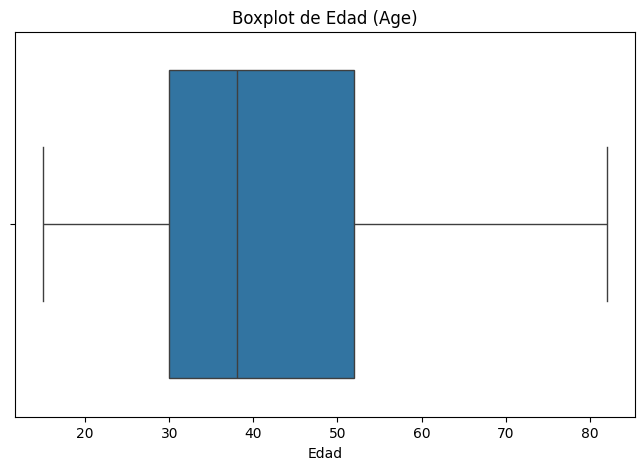

In [55]:
plt.style.use('default')

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_thyroid['Age'])
plt.title('Boxplot de Edad (Age)')
plt.xlabel('Edad')
plt.show()


El análisis de IQR para la variable Age no identificó valores atípicos (outliers). Todos los registros se encuentran dentro del rango esperado (entre el límite inferior y superior calculado), lo cual es consistente con lo observado en el boxplot, confirmando que la distribución de edades no presenta valores extremos.

#### Gráficos EDA